# **Desarrollo del análisis exploratorio**


## **Información del Dataset**

**Título:** Precios de las acciones de las 500 empresas más grandes por capitalización de mercado (últimos 5 años)

**Fuente:** Datos históricos extraídos de Yahoo Finance.

**Resumen:** El conjunto de datos comprende registros diarios de métricas de rendimiento de acciones para las 500 principales empresas a lo largo de un período de cinco años.

**Variables de Dataset:**
* **Fecha:** Fecha del registro bursátil.
* **Abrir:** Precio de apertura de la acción.
* **Alto:** Precio más alto del día.
* **Bajo:** Precio más bajo del día.
* **Cerrar:** Precio de cierre de la acción.
* **Volumen:** Volumen de acciones negociadas.
* **Dividendos:** Pagos de dividendos (si aplica).
* **Divisiones de acciones:** Información sobre divisiones de acciones (si aplica).
* **Compañía:** Símbolo de cotización de la empresa.

## Librerías y conjunto de datos

En esta sección se realizará la importación de las librerías necesarias y la carga del conjunto de datos que se utilizará en el análisis exploratorio.

In [8]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualizaciones
%matplotlib inline
sns.set_style('whitegrid')
sns.set_palette('viridis')

# Cargar el dataset desde la ruta especificada
# La ruta es 'datos/stock_details_5_years.csv'
try:
    df = pd.read_csv('C:\\Users\\johan\\OneDrive - Universidad del Norte\\Escritorio\\MachineLearning\\1er_tarea\\datos\\stock_details_5_years.csv')
    print("Dataset cargado correctamente.")
except FileNotFoundError:
    print("Error: Asegúrate de que el archivo 'stock_details_5_years.csv' esté en la carpeta 'datos'.")

Dataset cargado correctamente.


## 2. Descripción y Estructura del Dataset

En esta sección, obtendremos una visión de alto nivel del dataset para entender su forma, tipos de datos y la presencia de valores. Describiremos cada una de las variables del conjunto de datos.

In [9]:
# Mostrar las primeras 5 filas para una vista previa
print("--- Primeras 5 filas del DataFrame ---")
display(df.head())

# Obtener información general del DataFrame (tipos de datos, conteo de no-nulos)
print("\n--- Información general del DataFrame ---")
df.info()

# Estadísticas descriptivas para las variables numéricas
print("\n--- Estadísticas descriptivas de las variables numéricas ---")
display(df.describe())

--- Primeras 5 filas del DataFrame ---


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company
0,2018-11-29 00:00:00-05:00,43.829761,43.863354,42.639594,43.083508,167080000,0.00,0.0,AAPL
1,2018-11-29 00:00:00-05:00,104.769074,105.519257,103.534595,104.636131,28123200,0.00,0.0,MSFT
2,2018-11-29 00:00:00-05:00,54.176498,55.007500,54.099998,54.729000,31004000,0.00,0.0,GOOGL
3,2018-11-29 00:00:00-05:00,83.749496,84.499496,82.616501,83.678497,132264000,0.00,0.0,AMZN
4,2018-11-29 00:00:00-05:00,39.692784,40.064904,38.735195,39.037853,54917200,0.04,0.0,NVDA



--- Información general del DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 602962 entries, 0 to 602961
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Date          602962 non-null  object 
 1   Open          602962 non-null  float64
 2   High          602962 non-null  float64
 3   Low           602962 non-null  float64
 4   Close         602962 non-null  float64
 5   Volume        602962 non-null  int64  
 6   Dividends     602962 non-null  float64
 7   Stock Splits  602962 non-null  float64
 8   Company       602962 non-null  object 
dtypes: float64(6), int64(1), object(2)
memory usage: 41.4+ MB

--- Estadísticas descriptivas de las variables numéricas ---


,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,602962.000000,602962.000000,602962.000000,602962.000000,6.029620e+05,602962.00000,602962.000000
mean,140.074711,141.853492,138.276316,140.095204,5.895601e+06,0.00731,0.000344
std,275.401725,279.003191,271.895276,275.477969,1.381596e+07,0.12057,0.050607
min,1.052425,1.061195,1.026114,1.034884,0.000000e+00,0.00000,0.000000
25%,39.566159,40.056222,39.058151,39.563746,1.031500e+06,0.00000,0.000000
50%,79.177964,80.125563,78.193820,79.177906,2.228700e+06,0.00000,0.000000
75%,157.837190,159.746317,155.841609,157.847153,5.277400e+06,0.00000,0.000000
max,6490.259766,6525.000000,6405.000000,6509.350098,1.123003e+09,35.00000,20.000000


## 3. Análisis de Valores Faltantes

Este es un punto crucial del EDA. Aquí cuantificaremos la extensión de los valores nulos para entender la calidad de los datos, sin realizar ninguna modificación.

--- Conteo y Porcentaje de Valores Faltantes por Columna ---


,Valores Nulos,Porcentaje


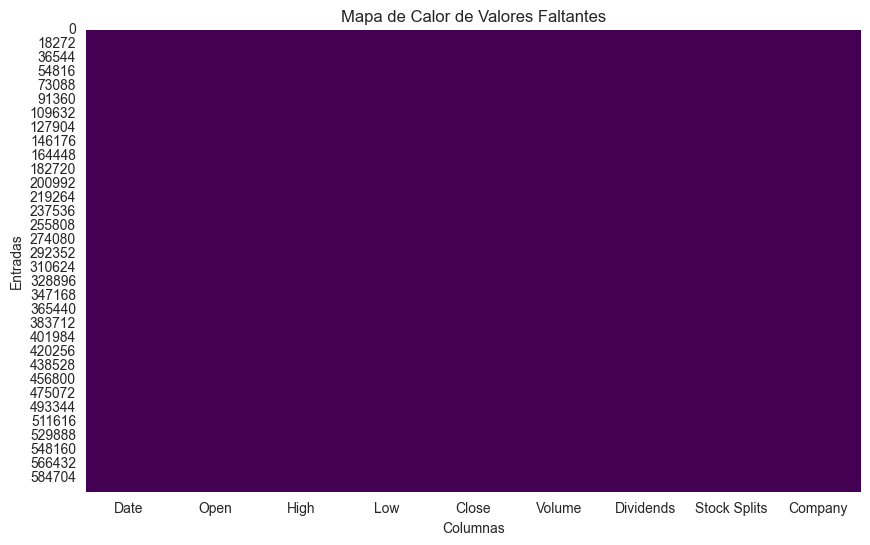

In [10]:
# Calcular el conteo y porcentaje de valores nulos por columna
valores_nulos = df.isnull().sum()
porcentaje_nulos = (valores_nulos / len(df)) * 100

# Crear un DataFrame para visualizar los nulos de manera clara
df_nulos = pd.DataFrame({'Valores Nulos': valores_nulos, 'Porcentaje': porcentaje_nulos})
df_nulos = df_nulos[df_nulos['Valores Nulos'] > 0].sort_values(by='Valores Nulos', ascending=False)

print("--- Conteo y Porcentaje de Valores Faltantes por Columna ---")
display(df_nulos)

# Visualizar la presencia de valores faltantes usando un mapa de calor
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de Calor de Valores Faltantes')
plt.xlabel('Columnas')
plt.ylabel('Entradas')
plt.show()

## 4. Análisis de la Distribución de Variables Clave

En esta sección, nos centraremos en las variables numéricas más importantes para entender cómo se distribuyen sus valores.

c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


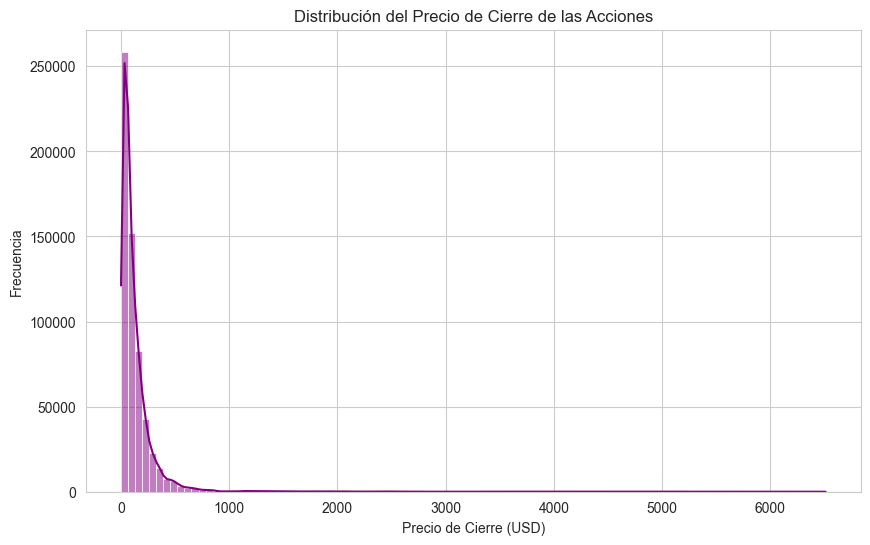

c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


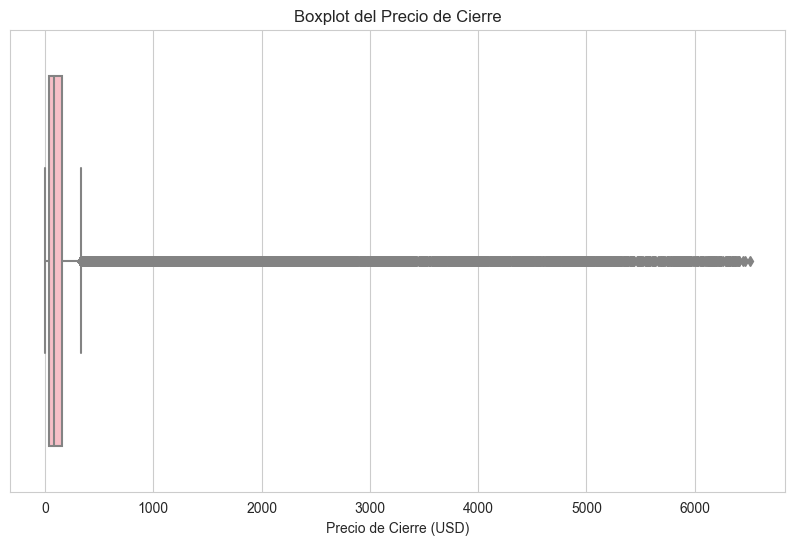

c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\johan\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


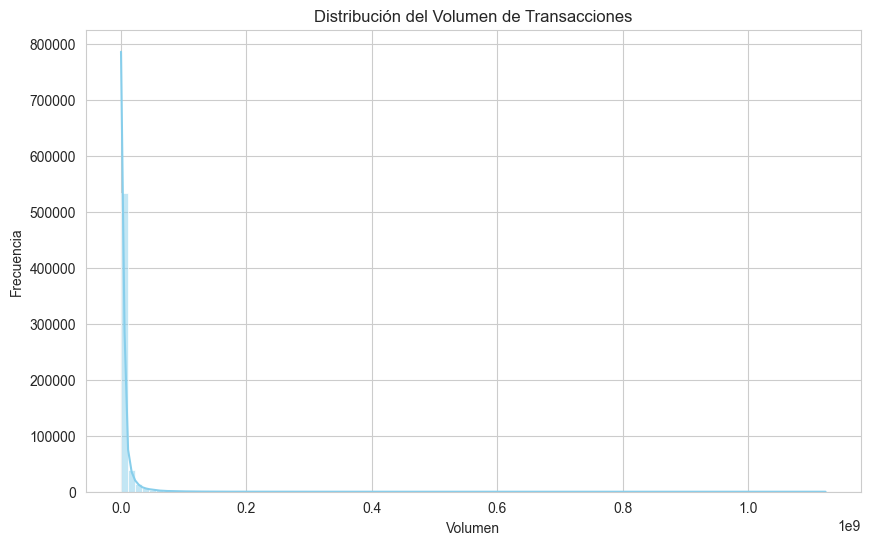


--- Top 10 empresas con más registros ---


Company
AAPL    1258
ARES    1258
FAST    1258
WCN     1258
FERG    1258
CSGP    1258
TTD     1258
VRSK    1258
FIS     1258
LYG     1258
Name: count, dtype: int64

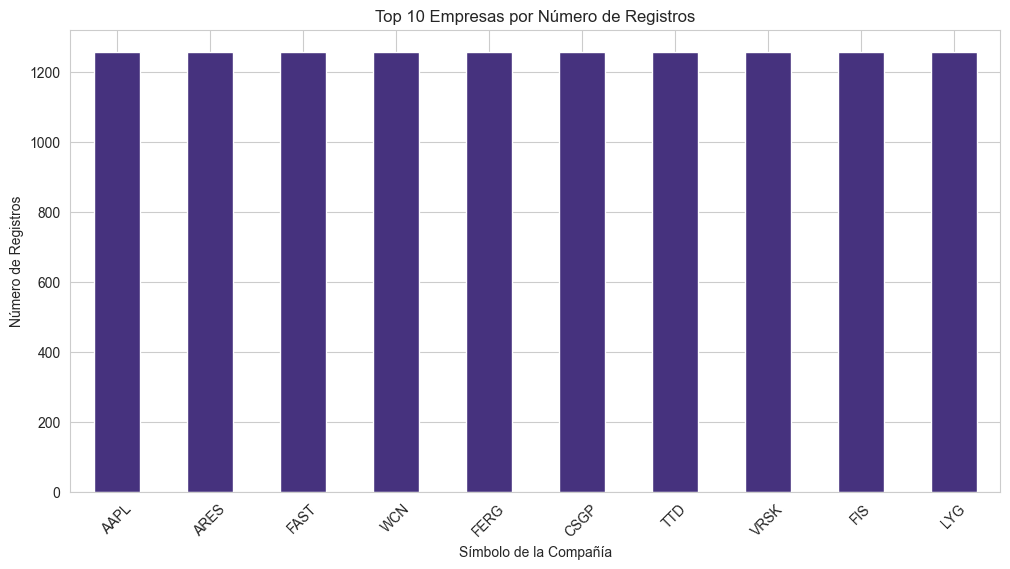

In [11]:
# Histograma para el precio de cierre (`Close`)
plt.figure(figsize=(10, 6))
sns.histplot(df['Close'], bins=100, kde=True, color='purple')
plt.title('Distribución del Precio de Cierre de las Acciones')
plt.xlabel('Precio de Cierre (USD)')
plt.ylabel('Frecuencia')
plt.show()

# Boxplot para identificar valores atípicos en el precio de cierre
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Close'], color='lightpink')
plt.title('Boxplot del Precio de Cierre')
plt.xlabel('Precio de Cierre (USD)')
plt.show()

# Histograma para el volumen (`Volume`)
plt.figure(figsize=(10, 6))
sns.histplot(df['Volume'], bins=100, kde=True, color='skyblue')
plt.title('Distribución del Volumen de Transacciones')
plt.xlabel('Volumen')
plt.ylabel('Frecuencia')
plt.show()

# Análisis de la variable categórica `Company`
print("\n--- Top 10 empresas con más registros ---")
display(df['Company'].value_counts().head(10))

plt.figure(figsize=(12, 6))
df['Company'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Empresas por Número de Registros')
plt.xlabel('Símbolo de la Compañía')
plt.ylabel('Número de Registros')
plt.xticks(rotation=45)
plt.show()

## 5. Análisis Bivariado y de Series de Tiempo

Aquí investigaremos la relación entre variables y su evolución en el tiempo.

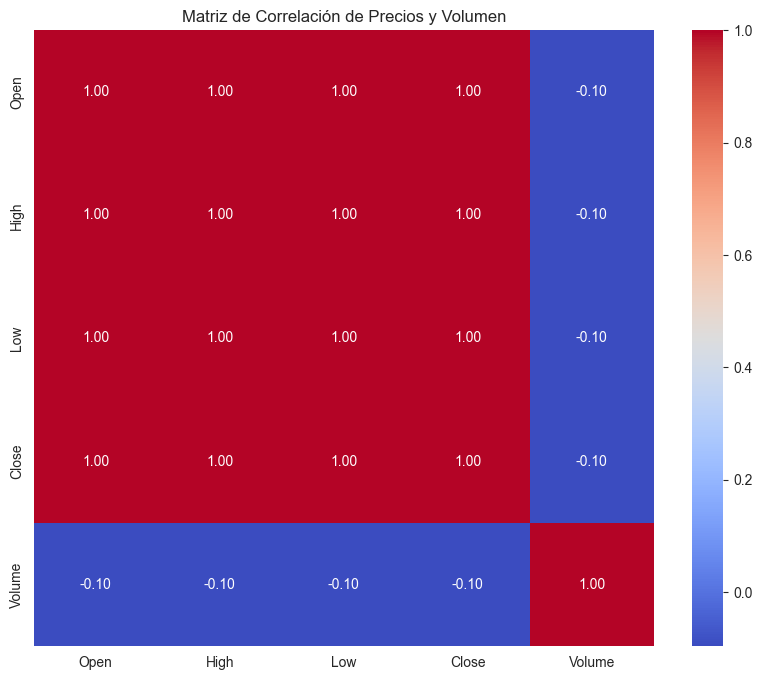

C:\Users\johan\AppData\Local\Temp\ipykernel_11156\3217971710.py:12: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise a warning unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Date'] = pd.to_datetime(df['Date'])


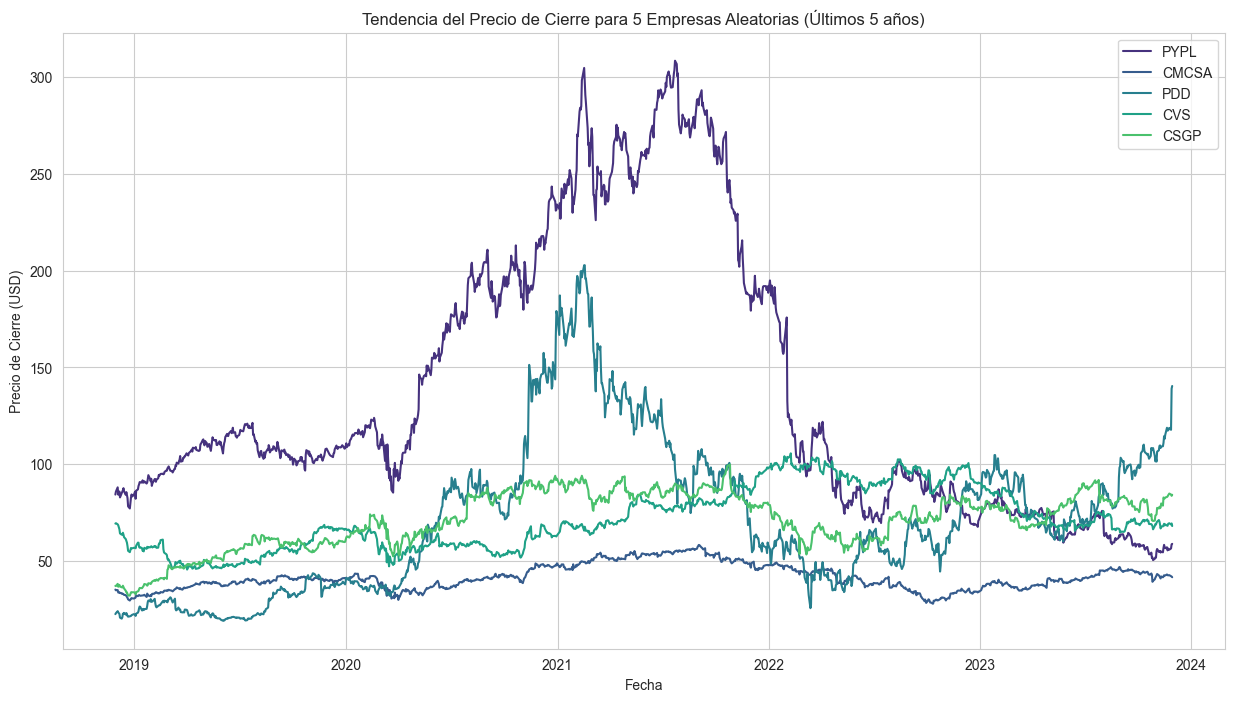

In [12]:
# Matriz de correlación de variables numéricas
# Se excluyen las variables con muchos nulos para un análisis más limpio
variables_numericas = ['Open', 'High', 'Low', 'Close', 'Volume']
correlacion = df[variables_numericas].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Precios y Volumen')
plt.show()

# Para el análisis de series de tiempo, primero convertimos la columna `Date`
df['Date'] = pd.to_datetime(df['Date'])
# Y ordenamos los datos para que el gráfico de series de tiempo sea correcto
df = df.sort_values(by=['Company', 'Date'])

# Seleccionamos 5 empresas aleatorias para visualizar su desempeño
empresas_aleatorias = np.random.choice(df['Company'].unique(), 5, replace=False)

plt.figure(figsize=(15, 8))
for company in empresas_aleatorias:
    # Filtramos los datos por cada empresa seleccionada
    df_empresa = df[df['Company'] == company]
    plt.plot(df_empresa['Date'], df_empresa['Close'], label=company)

plt.title('Tendencia del Precio de Cierre para 5 Empresas Aleatorias (Últimos 5 años)')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (USD)')
plt.legend()
plt.grid(True)
plt.show()

## 6. Conclusiones del EDA

* **Calidad de los datos:** Se identificaron valores faltantes en las columnas `Dividends` y `Stock Splits`, lo cual es una característica inherente a los datos de este tipo.
* **Estructura de los datos:** El dataset está bien estructurado. Las variables de precio (`Open`, `High`, `Low`, `Close`) y `Volume` están listas para el análisis. La variable `Date` es de tipo `object` y se ha convertido a `datetime` para el análisis de series de tiempo.
* **Distribución de variables:** Las variables de precio y volumen muestran distribuciones fuertemente sesgadas a la derecha, con un alto número de valores atípicos. Esto indica que la mayoría de los registros corresponden a precios y volúmenes bajos, con un subconjunto de valores extremadamente altos.
* **Correlación y tendencias:** La matriz de correlación muestra una alta correlación entre las variables de precio, lo cual es esperado. El análisis de series de tiempo revela la volatilidad y las tendencias a largo plazo en los precios de las acciones de diferentes empresas.